In [1]:
import os
import glob

import numpy as np
import xarray as xr

import csv
import pop_tools
import gsw

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
import cartopy
import matplotlib.ticker as ticker
from matplotlib import animation, gridspec
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

ccrs = cartopy.crs

In [2]:
# Copernicus widths in inches (converted from mm)
one_col = 3.27  # 83 mm
two_col = 6.85  # 174 mm

# Set defaults for Copernicus: 11 pt for all elements
plt.rcParams.update({
    'figure.figsize': (two_col, two_col * 0.6),
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']
})

# Copernicus-ready coastline
nature_coast = cartopy.feature.NaturalEarthFeature(
    'physical', 'land', '50m',
    linewidth=0.3, 
    edgecolor='black', 
    facecolor='whitesmoke'
)

# load and prepare data

In [3]:
ds_temp = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_TEMP_3.0_40_20.nc').roll(nlon=+100)
ds_salt = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_SALT_3.0_40_20.nc').roll(nlon=+100)
ds_hmxl = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_HMXL_3.0_40_20.nc').roll(nlon=+100)
ds_shf  = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_SHF_3.0_40_20.nc').roll(nlon=+100)
ds_n_heat  = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_N_HEAT_3.0_40_20_early_hist.nc')
ds_hmxl['HMXL']=ds_hmxl.HMXL*1e-2

In [4]:
path = '/Data/skd/scratch/innag3580/comp/composites/'
ds_smoc = xr.open_dataset(os.path.join(path, f'Above_combined_smoc_3.0_40_20.nc'))
ds_dmoc = xr.open_dataset(os.path.join(path, f'Above_combined_dmoc_3.0_40_20.nc'))
ds_bsf  = xr.open_dataset(os.path.join(path, f'Above_combined_bsf_3.0_40_20.nc')).roll(nlon=+100)

In [5]:
CT = gsw.conversions.CT_from_pt(ds_salt['SALT'], ds_temp['TEMP'])
sigma2 = gsw.density.sigma2(ds_salt['SALT'], CT)
sigma2 = xr.DataArray(sigma2, name='DENS2', dims=ds_temp['TEMP'].dims, coords=ds_temp['TEMP'].coords)

ds_dens = ds_temp
ds_dens = ds_dens.drop_vars('TEMP')
ds_dens['DENS2'] = sigma2

# contribution from salt only
mean_temp = ds_temp['TEMP'].isel(time=slice(0, 40)).mean('time')
mean_temp = mean_temp.expand_dims({'time': ds_salt['SALT'].time})
CT_salt = gsw.conversions.CT_from_pt(ds_salt['SALT'], mean_temp)
sigma2_salt = gsw.density.sigma2(ds_salt['SALT'], CT_salt)
sigma2_salt = xr.DataArray(sigma2_salt, name='DENS2',
                           dims=ds_salt['SALT'].dims,
                           coords=ds_salt['SALT'].coords)
ds_dens['DENS2_salt'] = sigma2_salt

# contribution from temp only
mean_salt = ds_salt['SALT'].isel(time=slice(0, 40)).mean('time')
mean_salt = mean_salt.expand_dims({'time': ds_temp['TEMP'].time})
CT_temp = gsw.conversions.CT_from_pt(mean_salt, ds_temp['TEMP'])
sigma2_temp = gsw.density.sigma2(mean_salt, CT_temp)
sigma2_temp = xr.DataArray(sigma2_temp, name='DENS2', 
                           dims=ds_temp['TEMP'].dims, 
                           coords=ds_temp['TEMP'].coords)
ds_dens['DENS2_temp'] = sigma2_temp

In [6]:
#ds_bsf = ds_bsf.assign_coords(TLAT=ds_temp.TLAT)
#ds_bsf = ds_bsf.assign_coords(TLAT=ds_temp.TLONG)

In [7]:
# masks
## for plotting
grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic':[
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [10.0, 80.0], 'TLONG': [260.0, 360.0]}}   
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}}]}
NA_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
NA_mask = NA_mask.sum('region')

## for local analysis
grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic': [
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [50.0, 65.0], 'TLONG': [200.0, 360.0]}}
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [50.0, 65.0], 'TLONG': [300.0, 360.0]}}]}
SPNA_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
SPNA_mask = SPNA_mask.sum('region')

## to plot BSF
grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic':[
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [10.0, 65.0], 'TLONG': [260.0, 360.0]}}   
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}, 'bounds': {'TLAT': [10.0, 65.0], 'TLONG': [260.0, 360.0]}}]}
BSF_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
BSF_mask = BSF_mask.sum('region').roll(nlon=-100)   

## hmxl analysys
path = "/Data/gfi/share/ModData/CMIP6/raw/ocean/piControl/CESM2/MLOTST/*.nc"
ds = xr.open_mfdataset(path, combine='by_coords')
mld_mean_ann_max = ds['mlotst'].groupby('time.year').max('time').mean('year')
mld_mask = xr.where(mld_mean_ann_max > 1000, 1, np.nan)
mld_mask = mld_mask.fillna(0)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/xarray/conventions.py:523: SerializationWarning: variable 'mlotst' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(
/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/xarray/conventions.py:523: SerializationWarning: variable 'mlotst' has multiple fill values {1e+20, 1e+20}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


# Flip books: BSF, TEMP, SALT

In [8]:
#this is to get the contours correctly
datasets = {
    'TEMP': ds_temp,
    'SALT': ds_salt,
}

# Define the replacement value
replacement_value = 0
# Iterate over the list of datasets and replace NaN, inf, and masked values
for ds in datasets.values():
    ds['TLAT'] = xr.where(
        np.logical_or(np.isnan(ds['TLAT']), np.isinf(ds['TLAT']) | np.ma.getmask(ds['TLAT'])),
        replacement_value,
        ds['TLAT']
    )
    ds['TLONG'] = xr.where(
        np.logical_or(np.isnan(ds['TLONG']), np.isinf(ds['TLONG']) | np.ma.getmask(ds['TLONG'])),
        replacement_value,
        ds['TLONG']
    )
    
datasets['BSF'] = ds_bsf

In [9]:
ds_vvel_original = xr.open_dataset('/Data/gfi/share/ModData/CESM2_LENS2/ocean/monthly/VVEL/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.VVEL.185001-185912.nc').roll(nlon=-100).isel(time=slice(0,3)).where(BSF_mask == 1) 

ds_vvel_original = ds_vvel_original.roll(nlon=+100)
ds_bsf = ds_bsf*1e-12
mask_test = BSF_mask.roll(nlon=+100)
ds_bsf = ds_bsf.where(mask_test == 1)

In [10]:
variables = ['BSF','TEMP', 'SALT']
labels = [r'$\Delta \psi_{b}$ [Sv]',
          r'$\Delta T$ [$^{\circ}$C]', 
          r'$\Delta S$ [g kg$^{-1}$]']
#cmaps = [cmo.balance, cmo.balance, cmo.tarn_r]
cmaps = [cm.seismic, cmo.balance, cmo.tarn_r]
vmins = [-8, -0.8, -0.3]
years_ranges = [(25, 35), (35, 45), (45, 55)]
column_names = ['Pre-Shift (25-35 years)', 'Shift (35-45 years)', 'Post-Shift (45-55 years)']

save_name = 'Figure_Increase_Flipbooks.png'


In [11]:
# set up weights
slice_upper_500  = slice(5e2, 5.5e3)
weights = (ds_temp.dz * ds_temp.TAREA).fillna(0)

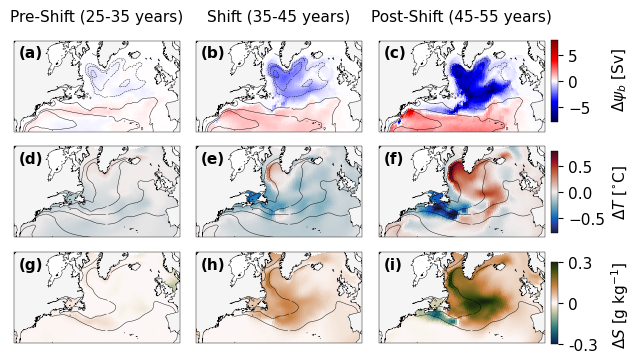

In [13]:
# --- Style & Label Prep ---
alphabet = 'abcdefghi'
label_idx = 0

fig, axes = plt.subplots(nrows=3, ncols=3, 
    subplot_kw={'projection': ccrs.Orthographic(central_latitude=35, central_longitude=-35)})

# BSF
replacement_value = 0
ds_vvel_original['ULAT'] = xr.where(
    np.logical_or(np.isnan(ds_vvel_original['ULAT']), np.isinf(ds_vvel_original['ULAT']) | np.ma.getmask(ds_vvel_original['ULAT'])),
    replacement_value,ds_vvel_original['ULAT'])
ds_vvel_original['ULONG'] = xr.where(
    np.logical_or(np.isnan(ds_vvel_original['ULONG']), np.isinf(ds_vvel_original['ULONG']) | np.ma.getmask(ds_vvel_original['ULONG'])),
    replacement_value,ds_vvel_original['ULONG'])
ds_bsf['ULAT'] = xr.where(
    np.logical_or(np.isnan(ds_bsf['ULAT']), np.isinf(ds_bsf['ULAT']) | np.ma.getmask(ds_bsf['ULAT'])),
    replacement_value,ds_bsf['ULAT'])

ds_var_annual = ds_bsf.BSF
ds = ds_var_annual - ds_var_annual.isel(time=slice(0, 40)).mean('time')
vmin = vmins[0]
vmax = -vmin

for col, (start, end) in enumerate(years_ranges):
    ax = axes[0, col]
    da = ds.isel(time=slice(start, end)).mean('time')
    pc = ax.pcolormesh(ds_vvel_original.ULONG, ds_vvel_original.ULAT, da, 
        transform=ccrs.PlateCarree(),cmap=cmaps[0], vmin=vmin, vmax=vmax)
    
    ax.set_extent([-90, -5, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(nature_coast)
    
    # Labeling logic
    ax.text(0.03, 0.95, f'({alphabet[label_idx]})', transform=ax.transAxes, 
            fontweight='bold', va='top', ha='left', zorder=15)
    label_idx += 1

    da_clim = ds_var_annual.isel(time=slice(0, 40)).mean('time')
    cs = ax.contour(ds_vvel_original.ULONG, ds_vvel_original.ULAT, da_clim, 
        linewidths=0.3, colors='k', transform=ccrs.PlateCarree())
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

# TEMP
ds_var_annual = ds_temp.TEMP.sel(z_t=slice_upper_500).weighted(weights).mean(dim='z_t')
ds = ds_var_annual - ds_var_annual.isel(time=slice(0, 40)).mean('time')
da_clim = ds_var_annual.isel(time=slice(0, 40)).mean('time').where(NA_mask == 1)
vmin = vmins[1]
vmax = -vmin
for col, (start, end) in enumerate(years_ranges):
    ax = axes[1, col]
    da = ds.isel(time=slice(start, end)).mean('time')
    pc = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), x='TLONG', y='TLAT',
        cmap=cmaps[1], vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_extent([-90, -5, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(nature_coast)
    
    # Labeling logic
    ax.text(0.03, 0.95, f'({alphabet[label_idx]})', transform=ax.transAxes, 
            fontweight='bold', va='top', ha='left', zorder=15)
    label_idx += 1

    cs = ax.contour(ds_temp.TLONG, ds_temp.TLAT, da_clim,
        linewidths=0.3, colors='k', transform=ccrs.PlateCarree())
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)
    
# SALT
ds_var_annual = ds_salt.SALT.sel(z_t=slice_upper_500).weighted(weights).mean(dim='z_t')
ds = ds_var_annual - ds_var_annual.isel(time=slice(0, 40)).mean('time')
da_clim = ds_var_annual.isel(time=slice(0, 40)).mean('time').where(NA_mask == 1)
vmin = vmins[2]
vmax = -vmin
for col, (start, end) in enumerate(years_ranges):
    ax = axes[2, col]
    da = ds.isel(time=slice(start, end)).mean('time')
    pc = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), x='TLONG', y='TLAT',
        cmap=cmaps[2], vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.set_extent([-90, -5, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(nature_coast)
    
    # Labeling logic: No bbox, shifted to x=0.06
    ax.text(0.03, 0.95, f'({alphabet[label_idx]})', transform=ax.transAxes, 
            fontweight='bold', va='top', ha='left', zorder=15)
    label_idx += 1

    cs = ax.contour(ds_salt.TLONG, ds_salt.TLAT, da_clim,
        linewidths=0.3, colors='k', transform=ccrs.PlateCarree())
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

cbar_axes = [fig.add_axes([0.91, 0.665- i * 0.27, 0.01, 0.2]) for i in range(3)]
for row in range(3):
    norm = plt.Normalize(vmin=vmins[row], vmax=-vmins[row])
    sm = plt.cm.ScalarMappable(cmap=cmaps[row], norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_axes[row])
    cbar.ax.set_ylabel('')
    
    # SALT specific
    if row == 2:
        cbar.set_ticks([-0.3, 0, 0.3])
        cbar.ax.set_yticklabels(['-0.3', '0', '0.3'])
    
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(0.3)

for i, label in enumerate(labels):
    fig.text(1.01, 0.77 - i * 0.275, label, verticalalignment='center', horizontalalignment='center', rotation=90)

for col, name in enumerate(column_names):
    axes[0, col].set_title(name, pad=14)
    
plt.subplots_adjust(wspace=0.1, hspace=0.01)
plt.savefig(save_name, bbox_inches='tight', dpi=300)

# Timeseries

In [8]:
# stream functions
smoc_55 = (ds_smoc.sMOC.isel(nlat=340).max('dens2')*1e-12)
dmoc_26 = (ds_dmoc.dMOC.isel(nlat=280).max('z_t')*1e-12)
bsf_spna = (ds_bsf.BSF.where(SPNA_mask == 1).min(dim=['nlat', 'nlon'])*1e-12)

In [9]:
# SPNA density 
ds_spna_dens = ds_dens.where(SPNA_mask == 1)
weights = ds_spna_dens.dz * ds_spna_dens.TAREA
weights = weights.fillna(0)
spna_dens = ds_spna_dens.DENS2.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])
spna_dens_salt = ds_spna_dens.DENS2_salt.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])
spna_dens_temp = ds_spna_dens.DENS2_temp.weighted(weights).sum(dim=['nlat', 'nlon', 'z_t'])

In [10]:
# hmxl in convection regions
ds_conv = ds_hmxl.where(mld_mask == 1)
weights = ds_conv.TAREA
weights = weights.fillna(0)
conv_hmxl = ds_conv.HMXL.weighted(weights).sum(dim=['nlat', 'nlon'])

In [11]:
# SPNA shf
ds_spna_shf = ds_shf.where(SPNA_mask == 1)
weights = ds_spna_shf.TAREA
weights = weights.fillna(0)
spna_shf = ds_shf.SHF.weighted(weights).sum(dim=['nlat', 'nlon'])

In [12]:
n_heat_45 = ds_n_heat.N_HEAT.isel(transport_reg=1, transport_comp=1).sel(lat_aux_grid=47.432735)

In [13]:
def normalise_time_series(timeseries):
    mean_initial = timeseries.isel(time=slice(0, 40)).mean('time')
    std_initial = timeseries.isel(time=slice(0, 40)).std('time')
    delta_timeseries = (timeseries - mean_initial) / std_initial
    return delta_timeseries

In [14]:

delta_spna_dens = normalise_time_series(spna_dens)
delta_spna_dens_salt = normalise_time_series(spna_dens_salt)
delta_spna_dens_temp = normalise_time_series(spna_dens_temp)

delta_conv_hmxl = normalise_time_series(conv_hmxl).rolling(time=3, center=True).mean()

delta_spna_shf = normalise_time_series(spna_shf).rolling(time=3, center=True).mean()
delta_n_heat_45 = normalise_time_series(n_heat_45).rolling(time=3, center=True).mean()

delta_smoc_55 = normalise_time_series(smoc_55)
delta_dmoc_26 = normalise_time_series(dmoc_26)
delta_bsf_spna = normalise_time_series(bsf_spna)

In [15]:
# --- Grayscale-Safe & Colorblind-Safe Palette ---
colors = {
    # Group 3: Density
    'spna_dens': '#000000',      
    'dens_salt': '#0072B2',      
    'dens_temp': '#E69F00',      
    
    # Group 2: Heat/MLD 
    'n_heat_45': '#D55E00',      
    'kwon_hmxl': '#FFFFFF',      # With black outline
    'spna_shf': '#56B4E9',       
    
    # Group 1: Dynamics (Strict Luminance Contrast for Achromatopsia)
    'smoc_55': '#016E89',    
    'dmoc26': '#2E104A',    
    'bsf_spna': '#FF6C93' 
}
linewidth = 1.5 # Slightly thicker for better visibility

/home/innag3580/.conda/envs/movie/lib/python3.10/site-packages/dask/array/reductions.py:640: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


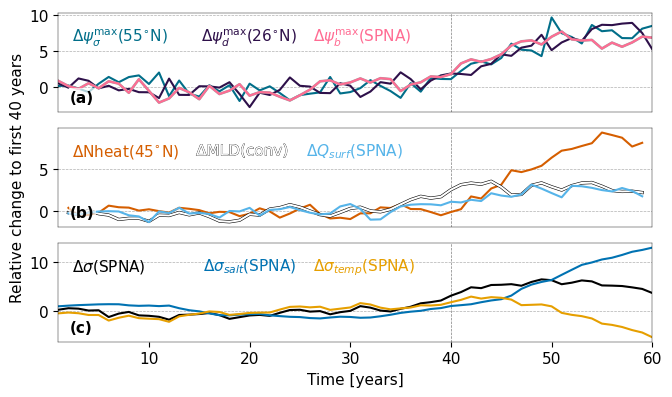

In [16]:
fig, axes = plt.subplots(nrows=3, ncols=1)

# --- APPLY SPINE WIDTHTO ALL SUBPLOTS ---
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

# --- Subplot 1 ---
axes[0].axvline(x=40, color='grey', linestyle='--', linewidth=0.5)
axes[0].plot(delta_smoc_55.time + 1, delta_smoc_55, linewidth=linewidth, color=colors['smoc_55'],
             label=r'$\Delta \psi^{\max}_{\sigma}(55^{\circ}$N)    ')
axes[0].plot(delta_dmoc_26.time + 1, delta_dmoc_26, linewidth=linewidth, color=colors['dmoc26'],
             label=r'$\Delta \psi^{\max}_{d}(26^{\circ}$N)')

# BSF with teal-blue contrast outline
axes[0].plot(delta_bsf_spna.time + 1, -delta_bsf_spna, linewidth=linewidth, color=colors['bsf_spna'],
             label=r'$\Delta \psi^{\max}_{b}$(SPNA)',
             path_effects=[pe.Stroke(linewidth=linewidth+0.4, foreground='#A0A0A0'), pe.Normal()])

# Label at the bottom left with white box
axes[0].text(0.02, 0.1, '(a)', transform=axes[0].transAxes, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

axes[0].set_xlim(1, 60)
axes[0].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
axes[0].legend(loc='upper left', frameon=False, handlelength=0, handletextpad=0, labelcolor='linecolor', 
               ncols=3, framealpha=.5, columnspacing=1.1)

# --- Subplot 2 ---
axes[1].axvline(x=40, color='grey', linestyle='--', linewidth=0.5)
axes[1].plot(delta_n_heat_45.time + 1, delta_n_heat_45, linewidth=linewidth, color=colors['n_heat_45'],
             label=r'$\Delta $Nheat$(45^{\circ}$N)')

# White line with black outline for MLD
axes[1].plot(delta_conv_hmxl.time + 1, delta_conv_hmxl, linewidth=linewidth, color=colors['kwon_hmxl'],
             label=r'$\Delta $MLD(conv)',
             path_effects=[pe.Stroke(linewidth=linewidth+0.8, foreground='black'), pe.Normal()])

axes[1].plot(delta_spna_shf.time + 1, -delta_spna_shf, linewidth=linewidth, color=colors['spna_shf'],
             label=r'$\Delta Q_{surf}$(SPNA)')

# Label at the bottom left with white box
axes[1].text(0.02, 0.1, '(b)', transform=axes[1].transAxes, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

axes[1].set_xlim(1, 60)
axes[1].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
axes[1].set_ylabel('Relative change to first 40 years', labelpad=10)

leg1 = axes[1].legend(loc='upper left', frameon=False, handlelength=0, handletextpad=0, labelcolor='linecolor', 
                      ncols=3, framealpha=.5, columnspacing=1.1)

for text in leg1.get_texts():
    if 'MLD(conv)' in text.get_text():
        text.set_path_effects([pe.Stroke(linewidth=0.4, foreground='black'), pe.Normal()])

# --- Subplot 3 ---
axes[2].axvline(x=40, color='grey', linestyle='--', linewidth=0.5)
axes[2].plot(delta_spna_dens.time + 1, delta_spna_dens, linewidth=linewidth, color=colors['spna_dens'],
             label=r'$\Delta \sigma$(SPNA)         ')
axes[2].plot(delta_spna_dens_salt.time + 1, delta_spna_dens_salt, linewidth=linewidth, color=colors['dens_salt'],
             label=r'$\Delta \sigma_{salt}$(SPNA)')
axes[2].plot(delta_spna_dens_temp.time + 1, delta_spna_dens_temp, linewidth=linewidth, color=colors['dens_temp'],
             label=r'$\Delta \sigma_{temp}$(SPNA)')

# Label at the bottom left with white box
axes[2].text(0.02, 0.1, '(c)', transform=axes[2].transAxes, fontweight='bold',
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

axes[2].set_xlabel('Time [years]')
axes[2].set_xlim(1, 60)
axes[2].yaxis.grid(True, which='both', linestyle='--', linewidth=0.5)
axes[2].legend(loc='upper left', frameon=False, handlelength=0, handletextpad=0, labelcolor='linecolor', 
               ncols=3, framealpha=.5, columnspacing=1.1)

plt.subplots_adjust(hspace=0.2)
plt.tight_layout()
plt.savefig('Figure_Increase_timeseries.png', bbox_inches='tight', dpi=300, transparent=False)